In [6]:
# func - bedpe to id
import matplotlib
#matplotlib.use('Agg')
from matplotlib import pyplot as plt
from matplotlib_venn import venn3

def load_bedpe_as_ids(path):
    ids = set()
    with open(path) as f:
        for line in f:
            if line.strip().startswith("#") or not line.strip():
                continue
            parts = line.strip().split('\t')
            if len(parts) < 6:
                continue
            chr1, start1, end1, chr2, start2, end2 = parts[:6]
            loop_id = (
                chr1, int(start1), int(end1),
                chr2, int(start2), int(end2)
            )
            ids.add(loop_id)
    return ids

In [7]:
peak = load_bedpe_as_ids("peakachu_merged_loops_ctrl.bedpe")
must = load_bedpe_as_ids("mustache_merged_loops_ctrl_fixed_clean.bedpe")
cool = load_bedpe_as_ids("cooldots_merged_loops_ctrl.bedpe")

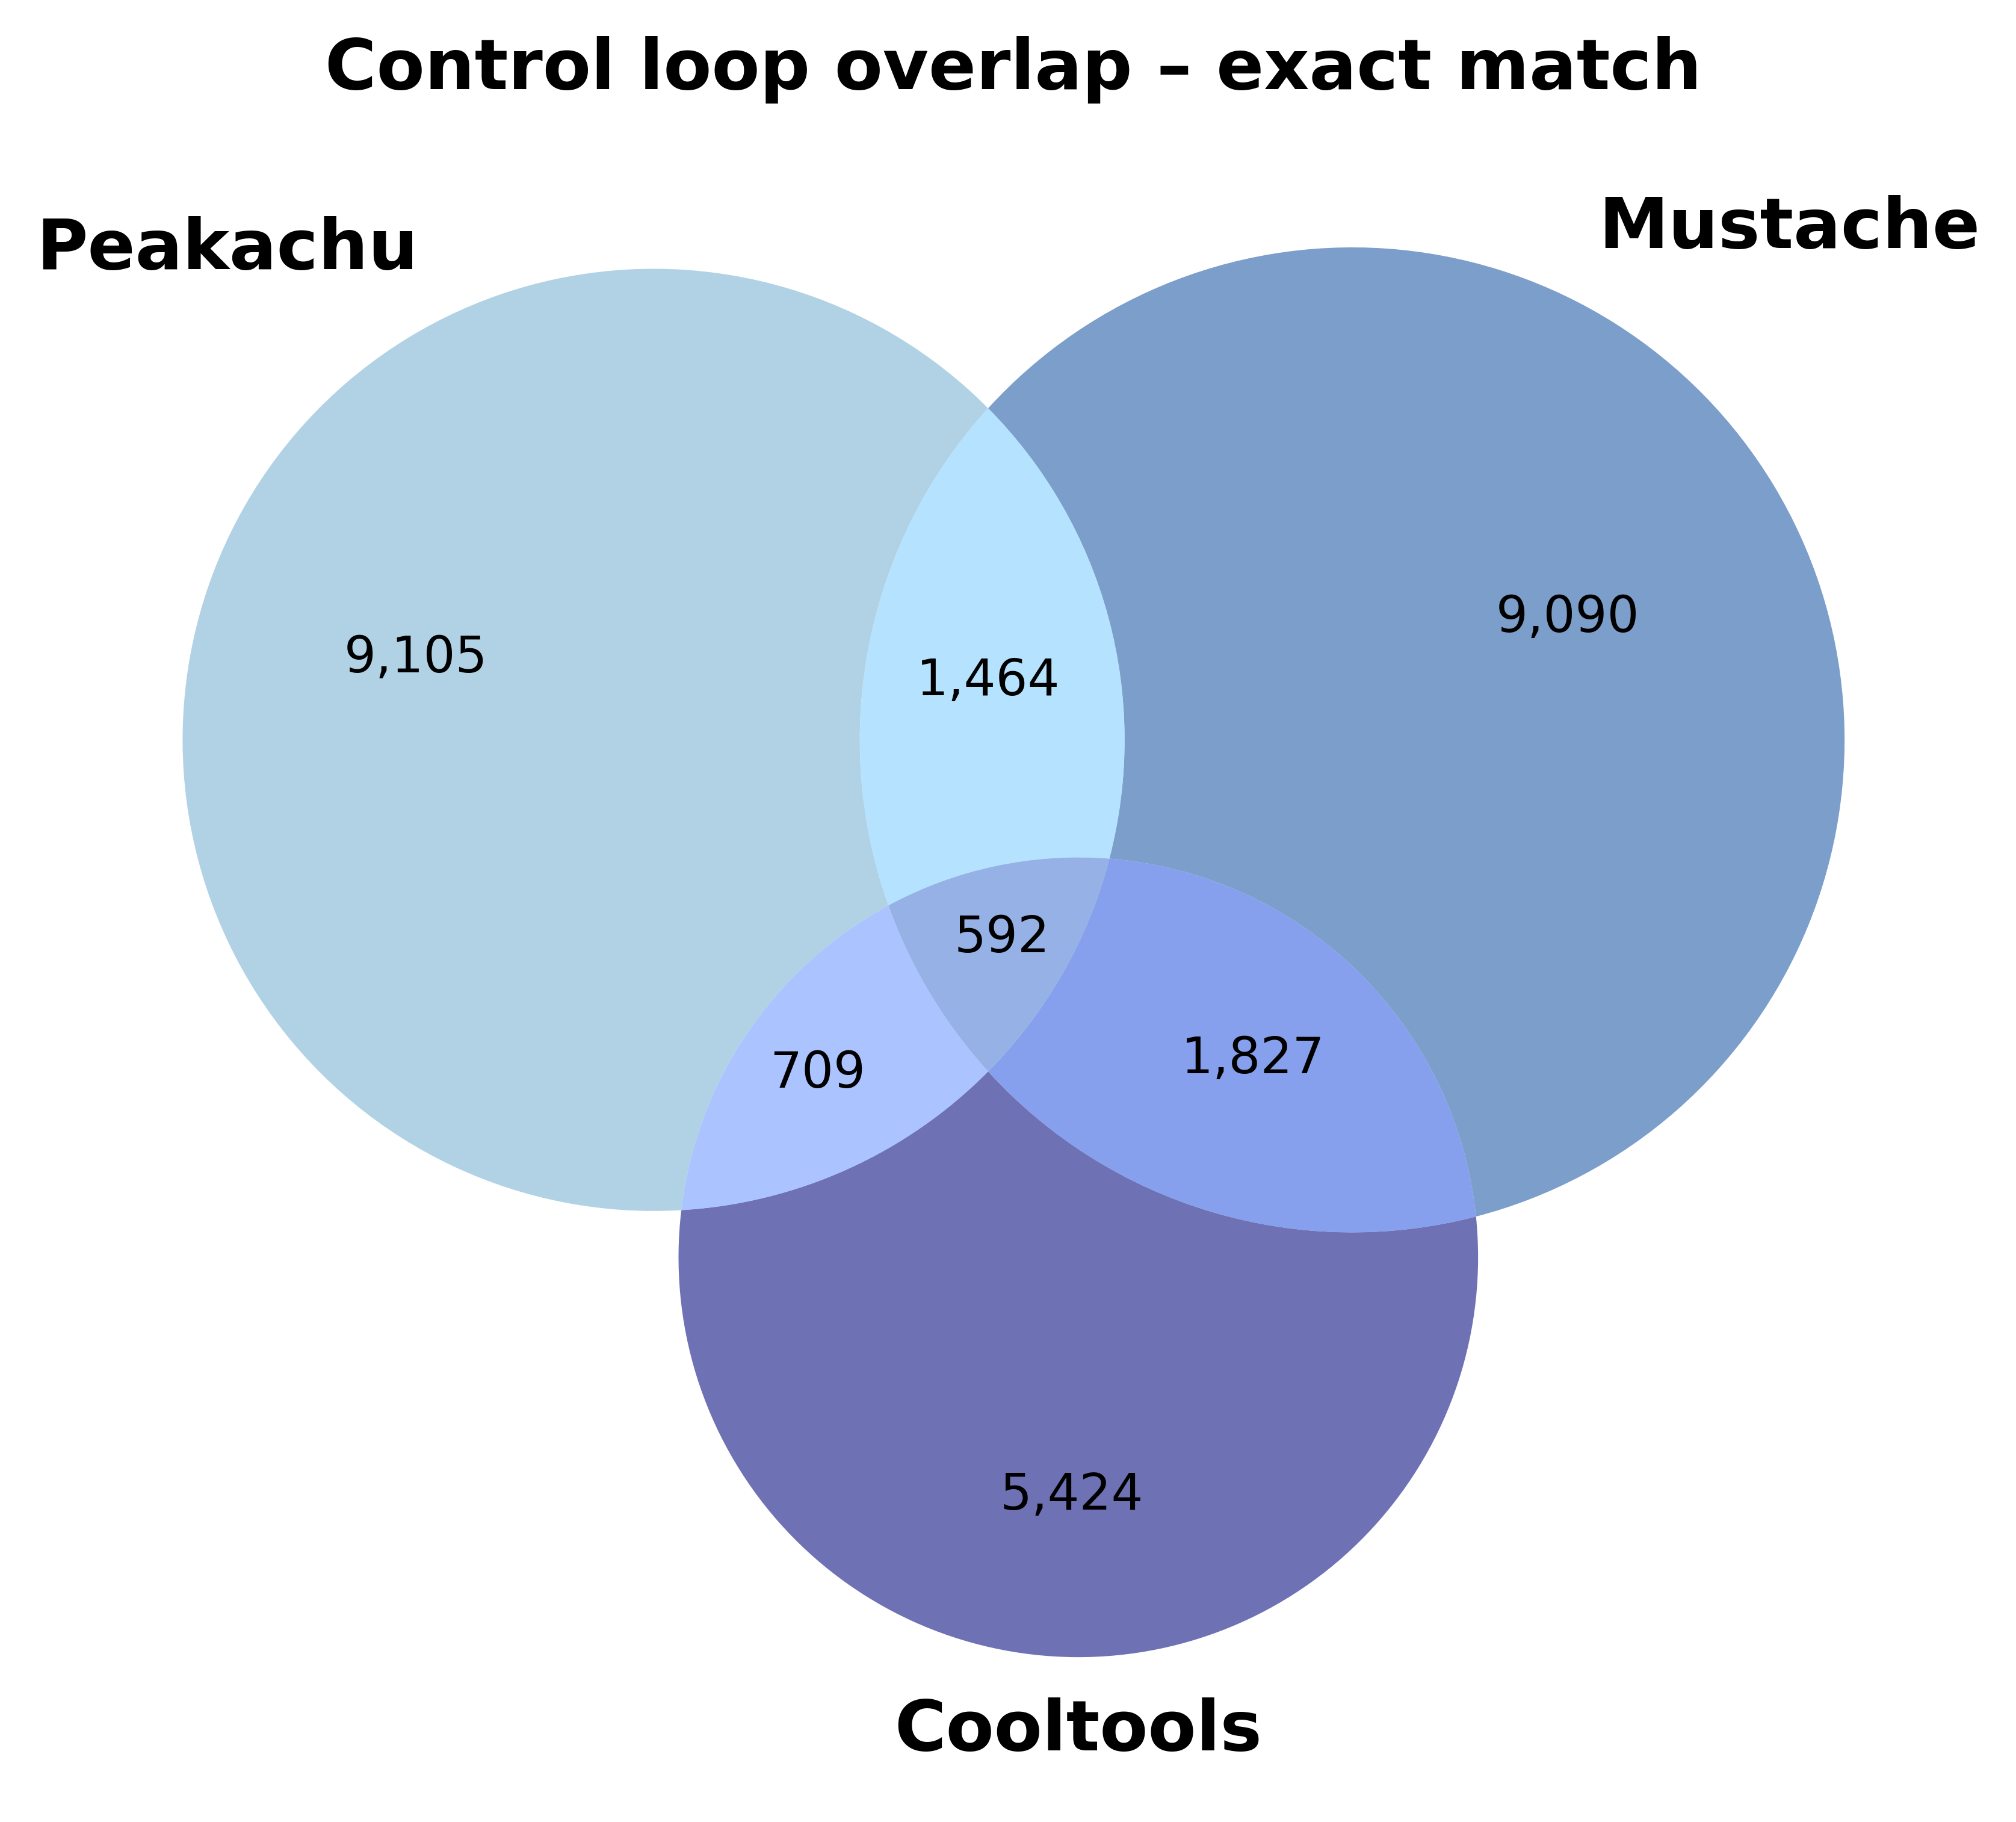

In [8]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn3
from matplotlib import rcParams

# Global font settings
rcParams['font.family'] = 'DejaVu Sans'
rcParams['font.size'] = 12

fig, ax = plt.subplots(figsize=(6, 6), dpi=600)

v = venn3([peak, must, cool],
          set_labels=["Peakachu", "Mustache", "Cooltools"],
          set_colors=["#91bfdb", "#4575b4", "#313695"],
          alpha=0.7,
          ax=ax)

# Enhance set labels
for text in v.set_labels:
    if text:
        text.set_fontsize(14)
        text.set_fontweight('bold')

# Enhance subset labels
for idx in range(1, 8):
    label = v.get_label_by_id(bin(idx)[2:].zfill(3))
    if label:
        label.set_fontsize(10)
        label.set_text(f"{int(label.get_text()):,}")

# Remove patch outlines
for patch in v.patches:
    if patch:
        patch.set_edgecolor('none')

plt.title("Control loop overlap – exact match", fontsize=14, weight='bold')
plt.tight_layout()
#plt.savefig("venn_ctrl_exact_highres.png", dpi=600, bbox_inches='tight', transparent=True)
plt.show()


In [9]:
print(*[f"total {i}: {len(j)}" for i, j in zip(["peak", "must", "cool"], (peak, must, cool))], sep="\n")

11870
12973
8552


In [10]:
peak = load_bedpe_as_ids("peakachu_merged_loops_rbp1.bedpe")
must = load_bedpe_as_ids("mustache_merged_loops_rbp1_fixed_clean.bedpe")
cool = load_bedpe_as_ids("cooldots_merged_loops_rbp1.bedpe")

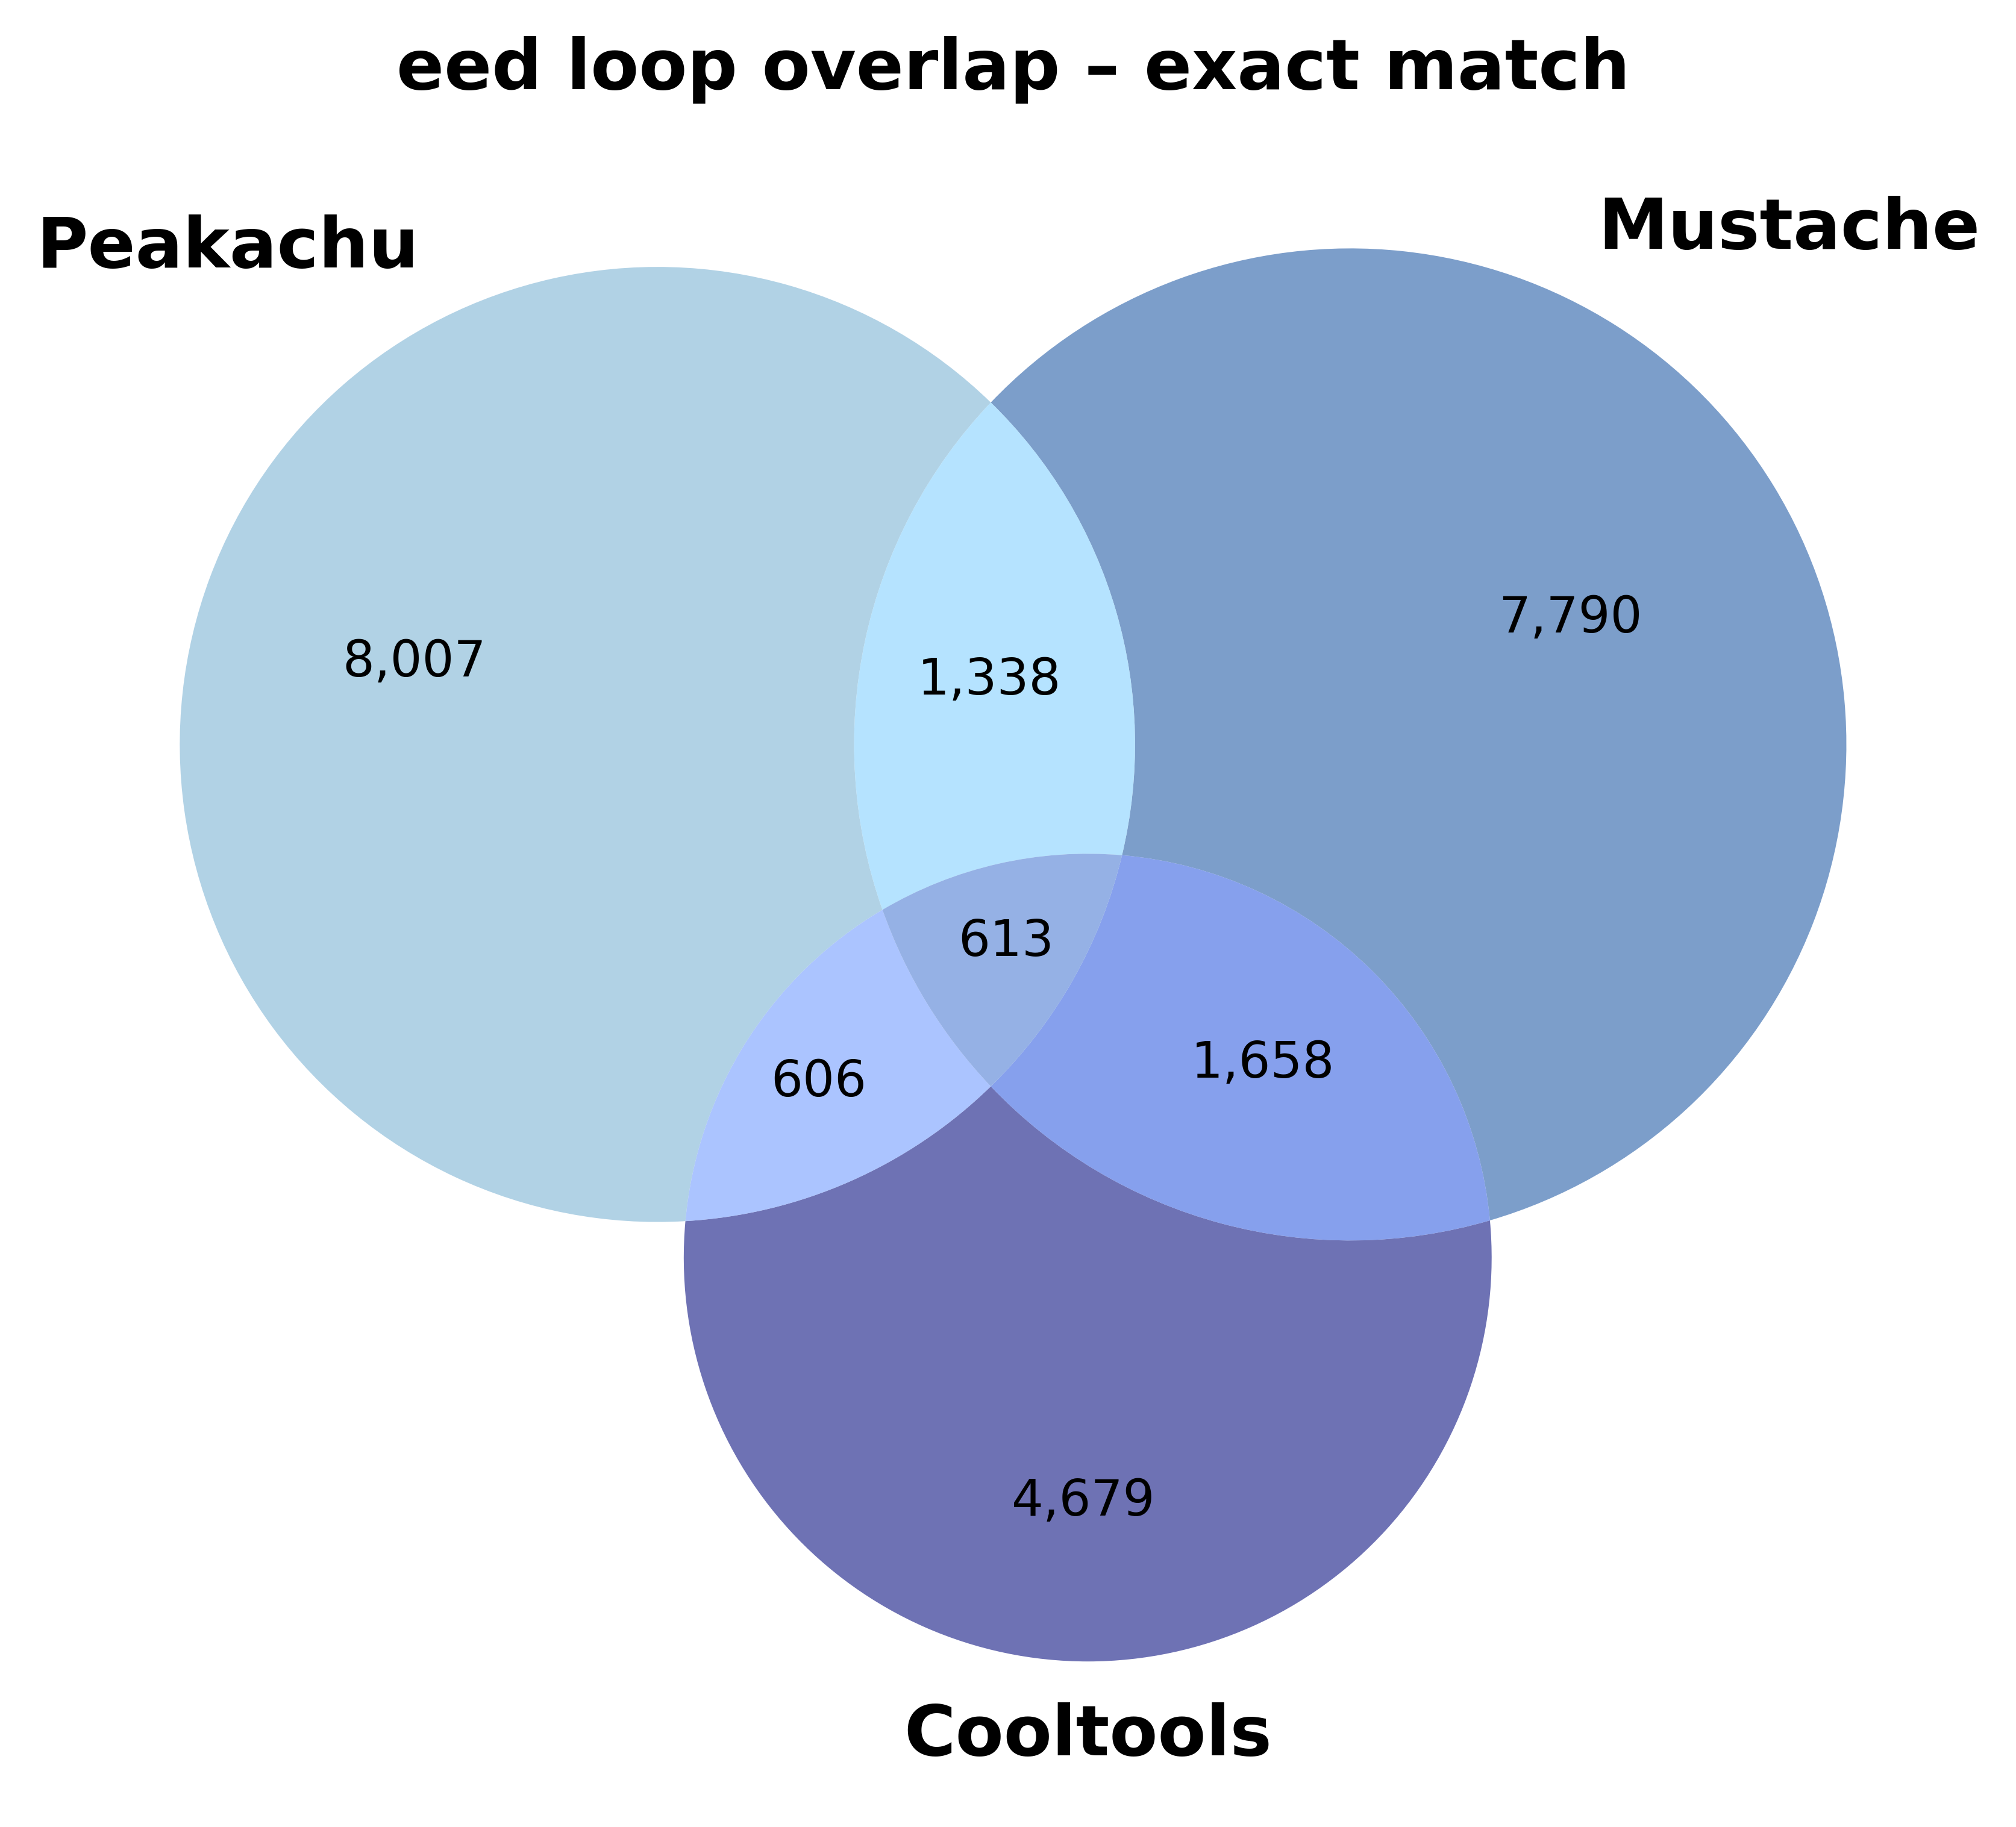

In [12]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn3
from matplotlib import rcParams

# Global font settings
rcParams['font.family'] = 'DejaVu Sans'
rcParams['font.size'] = 12

fig, ax = plt.subplots(figsize=(6, 6), dpi=600)

v = venn3([peak, must, cool],
          set_labels=["Peakachu", "Mustache", "Cooltools"],
          set_colors=["#91bfdb", "#4575b4", "#313695"],
          alpha=0.7,
          ax=ax)

# Enhance set labels
for text in v.set_labels:
    if text:
        text.set_fontsize(14)
        text.set_fontweight('bold')

# Enhance subset labels
for idx in range(1, 8):
    label = v.get_label_by_id(bin(idx)[2:].zfill(3))
    if label:
        label.set_fontsize(10)
        label.set_text(f"{int(label.get_text()):,}")

# Remove patch outlines
for patch in v.patches:
    if patch:
        patch.set_edgecolor('none')

plt.title("eed loop overlap – exact match", fontsize=14, weight='bold')
plt.tight_layout()
#plt.savefig("venn_ctrl_exact_highres.png", dpi=600, bbox_inches='tight', transparent=True)
plt.show()

In [32]:
ls = peak, must, cool
for i in ls:
    print(len(i))

10564
11399
7556


In [33]:
for name, obj in zip(["peak", "must", "cool"], (peak, must, cool)):
                     print(name)
                     print(len(obj))

peak
10564
must
11399
cool
7556


In [34]:
print(*[f"total {i}: {len(j)}" for i, j in zip(["peak", "must", "cool"], (peak, must, cool))], sep="\n")

total peak: 10564
total must: 11399
total cool: 7556
